
# 06 — Criteo Uplift Analytics

**Product Pulse**

Pre-modeling treatment-effect analytics on the cleaned Criteo Uplift dataset:

- treatment/control sizes
- intent-to-treat conversion and visit lift
- significance tests
- exposure descriptives
- feature balance
- exploratory heterogeneous lift on a sample

Actual uplift modeling is deferred to a later notebook.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "02_cleaned"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed data folder not found: {PROCESSED_DIR}\n"
        "Run 02_data_cleaning_and_validation.ipynb first."
    )


PROJECT_ROOT : /Users/noopur/Desktop/resume_projects/ProductPulse
PROCESSED_DIR: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned


In [2]:

from scipy.stats import chi2_contingency
CRITEO_DIR=PROCESSED_DIR/"criteo_uplift"
if not CRITEO_DIR.exists(): raise FileNotFoundError(CRITEO_DIR)
parquet_parts=sorted(CRITEO_DIR.glob("*.parquet"))
if not parquet_parts: raise FileNotFoundError(f"No parquet parts found in {CRITEO_DIR}")
print("Parquet parts:",len(parquet_parts)); print("First part:",parquet_parts[0].name)


Parquet parts: 28
First part: part_0000.parquet


## 1. Stream full dataset into compact aggregates

In [3]:

binary_cols=["treatment","conversion","visit","exposure"]; feature_cols=[f"f{i}" for i in range(12)]
aggregate_records=[]; sample_frames=[]; SAMPLE_PER_PART=5000; RNG_SEED=42
for part_index,part_path in enumerate(parquet_parts):
    batch=pd.read_parquet(part_path,columns=binary_cols+feature_cols)
    grouped=batch.groupby("treatment").agg(users=("treatment","size"),conversions=("conversion","sum"),visits=("visit","sum"),exposures=("exposure","sum")).reset_index(); aggregate_records.append(grouped)
    n_sample=min(SAMPLE_PER_PART,len(batch)); sample_frames.append(batch.sample(n=n_sample,random_state=RNG_SEED+part_index))
treatment_totals=pd.concat(aggregate_records,ignore_index=True).groupby("treatment",as_index=False).sum(numeric_only=True)
criteo_sample=pd.concat(sample_frames,ignore_index=True)
print("Sample rows:",f"{len(criteo_sample):,}"); display(treatment_totals)


Sample rows: 140,000


,treatment,users,conversions,visits,exposures
0,0,2081977,4063,80105,0
1,1,11770004,36711,576823,428193


## 2. Intent-to-treat outcomes

In [4]:

treatment_summary=treatment_totals.copy(); treatment_summary["conversion_rate"]=treatment_summary["conversions"]/treatment_summary["users"]; treatment_summary["visit_rate"]=treatment_summary["visits"]/treatment_summary["users"]; treatment_summary["exposure_rate"]=treatment_summary["exposures"]/treatment_summary["users"]; treatment_summary["group"]=treatment_summary["treatment"].map({0:"Control",1:"Treatment"}); display(treatment_summary[["group","users","conversions","conversion_rate","visits","visit_rate","exposures","exposure_rate"]])


,group,users,conversions,conversion_rate,visits,visit_rate,exposures,exposure_rate
0,Control,2081977,4063,0.001952,80105,0.038475,0,0.00000
1,Treatment,11770004,36711,0.003119,576823,0.049008,428193,0.03638


In [5]:

control=treatment_summary.loc[treatment_summary["treatment"]==0].iloc[0]; treated=treatment_summary.loc[treatment_summary["treatment"]==1].iloc[0]
effect_summary=pd.DataFrame([
{"outcome":"conversion","control_rate":control["conversion_rate"],"treatment_rate":treated["conversion_rate"],"absolute_lift":treated["conversion_rate"]-control["conversion_rate"],"relative_lift_pct":100*(treated["conversion_rate"]-control["conversion_rate"])/control["conversion_rate"] if control["conversion_rate"]>0 else np.nan},
{"outcome":"visit","control_rate":control["visit_rate"],"treatment_rate":treated["visit_rate"],"absolute_lift":treated["visit_rate"]-control["visit_rate"],"relative_lift_pct":100*(treated["visit_rate"]-control["visit_rate"])/control["visit_rate"] if control["visit_rate"]>0 else np.nan},
]); display(effect_summary)


,outcome,control_rate,treatment_rate,absolute_lift,relative_lift_pct
0,conversion,0.001952,0.003119,0.001168,59.826471
1,visit,0.038475,0.049008,0.010532,27.374432


## 3. Statistical significance

In [6]:

def binary_chi_square(success_control,n_control,success_treat,n_treat):
    contingency=np.array([[success_control,n_control-success_control],[success_treat,n_treat-success_treat]])
    chi2,p_value,dof,expected=chi2_contingency(contingency); return chi2,p_value
statistical_tests=[]
for outcome,success_col in [("conversion","conversions"),("visit","visits")]:
    chi2,p_value=binary_chi_square(int(control[success_col]),int(control["users"]),int(treated[success_col]),int(treated["users"]))
    statistical_tests.append({"outcome":outcome,"chi_square":chi2,"p_value":p_value,"statistically_significant_0_05":p_value<0.05})
statistical_tests=pd.DataFrame(statistical_tests); display(statistical_tests)


,outcome,chi_square,p_value,statistically_significant_0_05
0,conversion,821.235534,1.303613e-180,True
1,visit,4343.800189,0.000000e+00,True


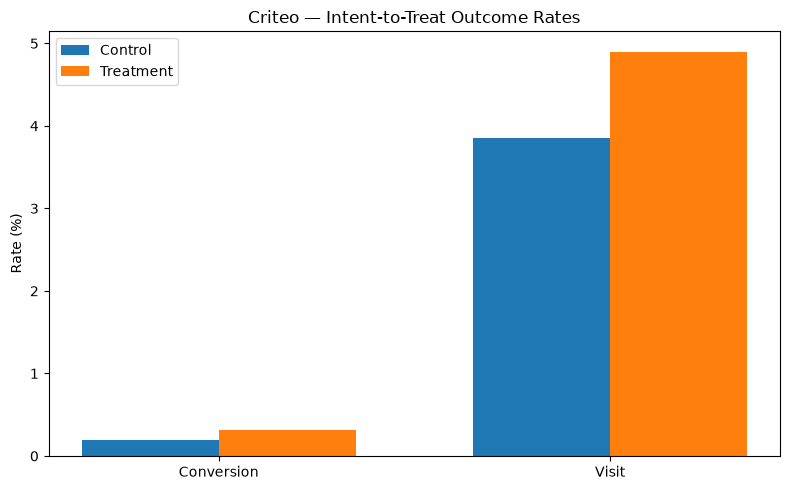

In [7]:

fig_effect,ax=plt.subplots(figsize=(8,5)); x=np.arange(len(effect_summary)); width=0.35
ax.bar(x-width/2,100*effect_summary["control_rate"],width,label="Control"); ax.bar(x+width/2,100*effect_summary["treatment_rate"],width,label="Treatment")
ax.set_xticks(x); ax.set_xticklabels(effect_summary["outcome"].str.title()); ax.set_ylabel("Rate (%)"); ax.set_title("Criteo — Intent-to-Treat Outcome Rates"); ax.legend(); fig_effect.tight_layout(); plt.show()


## 4. Exposure descriptives

In [8]:

exposure_summary=pd.DataFrame([{"treated_users":int(treated["users"]),"treated_exposed_users":int(treated["exposures"]),"treated_exposure_rate":treated["exposure_rate"],"control_exposure_rate":control["exposure_rate"]}]); display(exposure_summary)


,treated_users,treated_exposed_users,treated_exposure_rate,control_exposure_rate
0,11770004,428193,0.03638,0.0


## 5. Treatment/control feature balance on sample

In [9]:

balance_rows=[]
for feature in feature_cols:
    cvals=criteo_sample.loc[criteo_sample["treatment"]==0,feature].dropna(); tvals=criteo_sample.loc[criteo_sample["treatment"]==1,feature].dropna(); mc=cvals.mean(); mt=tvals.mean(); vc=cvals.var(ddof=1); vt=tvals.var(ddof=1); pooled=np.sqrt((vc+vt)/2); smd=(mt-mc)/pooled if pooled and np.isfinite(pooled) else np.nan; balance_rows.append({"feature":feature,"control_mean":mc,"treatment_mean":mt,"standardized_mean_difference":smd,"abs_smd":abs(smd) if pd.notna(smd) else np.nan})
feature_balance=pd.DataFrame(balance_rows).sort_values("abs_smd",ascending=False).reset_index(drop=True); display(feature_balance)


,feature,control_mean,treatment_mean,standardized_mean_difference,abs_smd
0,f3,4.240733,4.165210,-0.058313,0.058313
1,f6,-3.988330,-4.210556,-0.049055,0.049055
2,f1,10.066745,10.071120,0.043945,0.043945
3,f5,4.042133,4.025610,-0.039835,0.039835
4,f9,15.875235,16.091562,0.031206,0.031206
5,f7,5.075467,5.102975,0.023319,0.023319
6,f8,3.934266,3.933063,-0.021383,0.021383
7,f2,8.451620,8.446970,-0.015473,0.015473
8,f0,19.650581,19.610406,-0.007441,0.007441
9,f11,-0.170974,-0.171019,-0.001979,0.001979


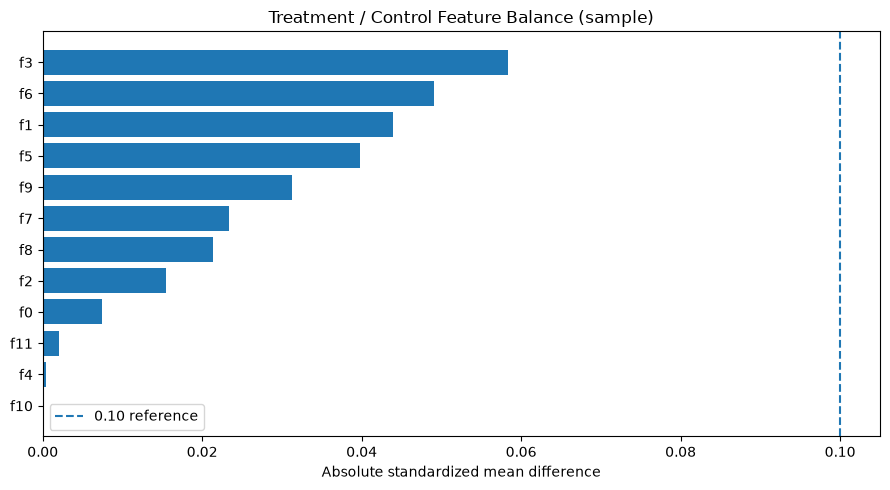

In [10]:

fig_balance,ax=plt.subplots(figsize=(9,5)); pb=feature_balance.sort_values("abs_smd"); ax.barh(pb["feature"],pb["abs_smd"]); ax.axvline(0.1,linestyle="--",label="0.10 reference"); ax.set_title("Treatment / Control Feature Balance (sample)"); ax.set_xlabel("Absolute standardized mean difference"); ax.legend(); fig_balance.tight_layout(); plt.show()


## 6. Exploratory heterogeneous conversion lift

In [11]:

hetero_sample=criteo_sample[["f0","treatment","conversion"]].dropna().copy(); hetero_sample["f0_bin"]=pd.qcut(hetero_sample["f0"],q=10,duplicates="drop")
hetero_rates=hetero_sample.groupby(["f0_bin","treatment"],observed=True)["conversion"].agg(["mean","size"]).reset_index(); hp=hetero_rates.pivot(index="f0_bin",columns="treatment",values="mean"); hc=hetero_rates.pivot(index="f0_bin",columns="treatment",values="size")
hetero_lift=pd.DataFrame({"f0_bin":hp.index.astype(str),"control_conversion_rate":hp.get(0,np.nan),"treatment_conversion_rate":hp.get(1,np.nan),"control_n":hc.get(0,np.nan),"treatment_n":hc.get(1,np.nan)}).reset_index(drop=True); hetero_lift["absolute_lift"]=hetero_lift["treatment_conversion_rate"]-hetero_lift["control_conversion_rate"]; display(hetero_lift)


,f0_bin,control_conversion_rate,treatment_conversion_rate,control_n,treatment_n,absolute_lift
0,"(12.615, 13.915]",0.002808,0.004608,6410,35590,0.001800
1,"(13.915, 18.092]",0.009326,0.010439,1930,12070,0.001113
2,"(18.092, 21.915]",0.003296,0.004042,2124,11876,0.000746
3,"(21.915, 22.785]",0.000489,0.000753,2044,11956,0.000264
4,"(22.785, 24.018]",0.000000,0.001513,2107,11893,0.001513
5,"(24.018, 24.844]",0.000000,0.000588,2103,11897,0.000588
6,"(24.844, 25.993]",0.000000,0.000506,2152,11848,0.000506
7,"(25.993, 26.745]",0.000000,0.000170,2204,11796,0.000170


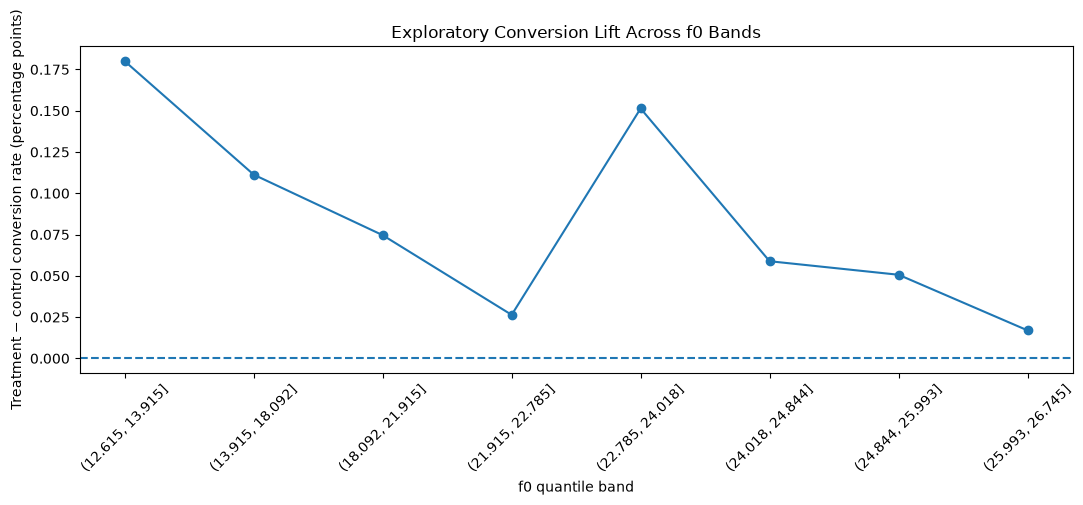

In [12]:

fig_hetero,ax=plt.subplots(figsize=(11,5)); ax.plot(hetero_lift["f0_bin"],100*hetero_lift["absolute_lift"],marker="o"); ax.axhline(0,linestyle="--"); ax.set_title("Exploratory Conversion Lift Across f0 Bands"); ax.set_xlabel("f0 quantile band"); ax.set_ylabel("Treatment − control conversion rate (percentage points)"); ax.tick_params(axis="x",rotation=45); fig_hetero.tight_layout(); plt.show()


## 7. Save compact results

In [13]:

RESULTS_DIR=PROJECT_ROOT/"results"/"06_criteo_uplift_analysis"; TABLES_DIR=RESULTS_DIR/"tables"; FIGURES_DIR=RESULTS_DIR/"figures"; TABLES_DIR.mkdir(parents=True,exist_ok=True); FIGURES_DIR.mkdir(parents=True,exist_ok=True)
RESULT_TABLES={"treatment_summary":treatment_summary,"effect_summary":effect_summary,"statistical_tests":statistical_tests,"exposure_summary":exposure_summary,"feature_balance_sample":feature_balance,"heterogeneous_lift_f0_sample":hetero_lift}
RESULT_FIGURES={"intent_to_treat_outcome_rates":fig_effect,"feature_balance_sample":fig_balance,"heterogeneous_lift_f0_sample":fig_hetero}
for name,table in RESULT_TABLES.items(): table.to_csv(TABLES_DIR/f"{name}.csv",index=False)
for name,fig in RESULT_FIGURES.items(): fig.savefig(FIGURES_DIR/f"{name}.png",dpi=200,bbox_inches="tight")
print(f"Tables saved : {len(RESULT_TABLES)}"); print(f"Figures saved: {len(RESULT_FIGURES)}"); print("Saved to:",RESULTS_DIR)


Tables saved : 6
Figures saved: 3
Saved to: /Users/noopur/Desktop/resume_projects/ProductPulse/results/06_criteo_uplift_analysis
